# Лабораторная работа
## Сжатие цветного изображения с помощью SVD

В этой работе я построю цветное изображение, разложу каждый его RGB-канал методом сингулярного разложения и восстановлю картинку для разных рангов. Затем я сравню качество восстановления, объём хранения и коэффициент сжатия.

**Почему изображение создаётся в ноутбуке:** исходный файл картинки в задании не приложен. Поэтому ноутбук полностью самодостаточный и запускается без дополнительных файлов.

In [1]:
# Подключаю модуль для поиска установленных библиотек.
import importlib.util
# Подключаю sys, чтобы использовать именно Python текущего ядра VS Code.
import sys
# Подключаю subprocess для запуска установки пакетов через текущий Python.
import subprocess
# Создаю список библиотек, которых может не быть в окружении.
packages_to_install = []
# Проверяю, установлен ли NumPy.
if importlib.util.find_spec("numpy") is None:
    packages_to_install.append("numpy")
# Проверяю, установлен ли Matplotlib.
if importlib.util.find_spec("matplotlib") is None:
    packages_to_install.append("matplotlib")
# Проверяю, установлена ли библиотека Pillow с модулем PIL.
if importlib.util.find_spec("PIL") is None:
    packages_to_install.append("pillow")
# Устанавливаю только отсутствующие библиотеки.
if packages_to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *packages_to_install])
# Вывожу сообщение, если все библиотеки уже были установлены.
else:
    print("Все необходимые библиотеки уже установлены.")


Все необходимые библиотеки уже установлены.


In [2]:
# Подключаю NumPy для работы с массивами и матрицами.
import numpy as np
# Подключаю Matplotlib для показа изображений и графиков.
import matplotlib.pyplot as plt
# Подключаю Path для создания папки с результатами.
from pathlib import Path
# Подключаю Image для сохранения массивов в формате PNG.
from PIL import Image
# Настраиваю размер рисунков.
plt.rcParams["figure.figsize"] = (12, 8)
# Включаю сетку на обычных графиках.
plt.rcParams["axes.grid"] = True
# Настраиваю вывод чисел.
np.set_printoptions(precision=4, suppress=True)

## Часть А. Создание и подготовка цветного изображения

Для продвинутого варианта я оставляю три цветовых канала: красный, зелёный и синий. SVD будет применяться к каждому каналу отдельно.

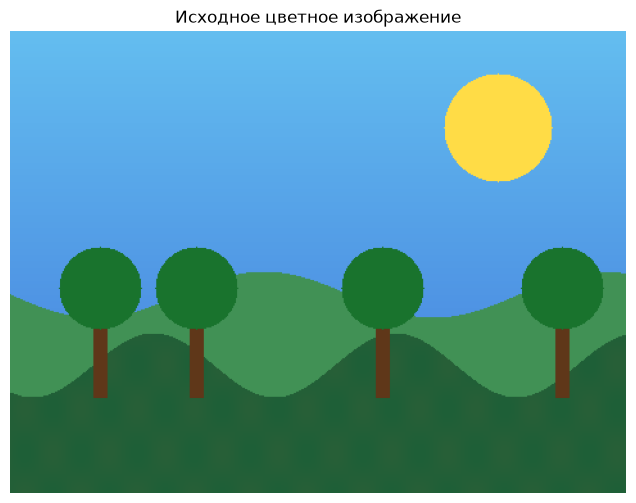

In [3]:
# Задаю высоту изображения не меньше 300 пикселей.
height = 360
# Задаю ширину изображения не меньше 300 пикселей.
width = 480
# Создаю координаты всех пикселей по вертикали и горизонтали.
y, x = np.mgrid[0:height, 0:width]
# Создаю пустой массив для цветного изображения RGB.
image_array = np.zeros((height, width, 3), dtype=float)
# Нормирую вертикальную координату от 0 до 1.
vertical = y / (height - 1)
# Заполняю небо плавным переходом от светло-синего к более тёмному.
image_array[..., 0] = 100 - 35 * vertical
# Заполняю зелёный канал неба.
image_array[..., 1] = 190 - 70 * vertical
# Заполняю синий канал неба.
image_array[..., 2] = 240 - 20 * vertical
# Создаю маску круглого солнца.
sun_mask = (x - 380) ** 2 + (y - 75) ** 2 <= 42 ** 2
# Делаю солнце жёлтым.
image_array[sun_mask] = [255, 220, 70]
# Вычисляю верхнюю границу дальнейшего холма.
far_hill_top = 205 + 18 * np.sin(x / 42)
# Выбираю пиксели, которые находятся на дальнем холме.
far_hill_mask = y >= far_hill_top
# Закрашиваю дальний холм зелёным цветом.
image_array[far_hill_mask] = [65, 145, 85]
# Вычисляю верхнюю границу переднего холма.
near_hill_top = 260 + 25 * np.sin(x / 30 + 1)
# Выбираю пиксели переднего холма.
near_hill_mask = y >= near_hill_top
# Закрашиваю передний холм более тёмным цветом.
image_array[near_hill_mask] = [35, 95, 55]
# Добавляю небольшую детерминированную текстуру переднему холму.
texture = 5 * np.sin(x / 7) * np.sin(y / 11)
# Добавляю текстуру только к красному каналу холма.
image_array[near_hill_mask, 0] += texture[near_hill_mask]
# Создаю маску стволов нескольких деревьев.
for center_x in [70, 145, 290, 430]:
    # Выбираю прямоугольник ствола очередного дерева.
    trunk_mask = (x >= center_x - 5) & (x <= center_x + 5) & (y >= 205) & (y <= 285)
    # Закрашиваю ствол коричневым цветом.
    image_array[trunk_mask] = [95, 55, 25]
    # Выбираю круглую крону дерева.
    crown_mask = (x - center_x) ** 2 + (y - 200) ** 2 <= 32 ** 2
    # Закрашиваю крону зелёным цветом.
    image_array[crown_mask] = [25, 115, 45]
# Ограничиваю значения каналов диапазоном 0...255.
image_array = np.clip(image_array, 0, 255)
# Перевожу изображение в целые однобайтные значения для показа и PNG.
original_uint8 = image_array.astype(np.uint8)
# Запоминаю форму исходного изображения для автопроверки.
original_shape = original_uint8.shape
# Показываю исходную цветную картинку.
plt.figure(figsize=(8, 6))
# Передаю массив в функцию отображения.
plt.imshow(original_uint8)
# Подписываю рисунок.
plt.title("Исходное цветное изображение")
# Убираю деления на осях, потому что это изображение.
plt.axis("off")
# Показываю рисунок.
plt.show()

## Часть Б. SVD и восстановление изображения

Для каждой цветовой матрицы я вычисляю разложение

```text
A = U · Sigma · V^T
```

Затем оставляю только первые `r` сингулярных чисел. Чем больше `r`, тем больше деталей сохраняется и тем больше объём сжатого представления.

In [4]:
# Создаю список для хранения SVD каждого из трёх каналов.
svd_factors = []
# Перебираю красный, зелёный и синий каналы.
for channel in range(3):
    # Беру одну цветовую матрицу размера height x width.
    channel_matrix = image_array[:, :, channel]
    # Выполняю SVD с компактными матрицами для экономии памяти.
    U, singular_values, Vt = np.linalg.svd(channel_matrix, full_matrices=False)
    # Сохраняю три части разложения для текущего канала.
    svd_factors.append((U, singular_values, Vt))
# Наименьший размер матрицы задаёт максимальный возможный ранг.
max_rank = min(height, width)
# Задаю обязательные ранги из условия.
list_of_ranks = [1, 5, 10, 30, 100, max_rank]
# Удаляю возможные повторы и оставляю только допустимые ранги.
list_of_ranks = sorted(set(min(max(1, r), max_rank) for r in list_of_ranks))
# Печатаю размеры факторов первого канала.
print("Размер U первого канала:", svd_factors[0][0].shape)
# Печатаю количество сингулярных чисел.
print("Количество сингулярных чисел:", len(svd_factors[0][1]))
# Показываю первые десять сингулярных чисел красного канала.
print("Первые 10 сингулярных чисел:", svd_factors[0][1][:10])


def reconstruct_rgb(rank):
    """Восстанавливает RGB-изображение по первым rank сингулярным числам."""
    # Создаю список восстановленных каналов.
    reconstructed_channels = []
    # Перебираю сохранённые разложения трёх каналов.
    for U, singular_values, Vt in svd_factors:
        # Умножаю столбцы U на сингулярные числа без создания большой диагональной матрицы.
        left_part = U[:, :rank] * singular_values[:rank]
        # Восстанавливаю один канал матричным умножением.
        channel = left_part @ Vt[:rank, :]
        # Добавляю восстановленный канал в список.
        reconstructed_channels.append(channel)
    # Объединяю три восстановленных канала в цветной массив.
    return np.stack(reconstructed_channels, axis=2)

Размер U первого канала: (360, 360)
Количество сингулярных чисел: 360
Первые 10 сингулярных чисел: [33897.6006  7149.3838  3575.1574  2693.4801  2390.1456  1639.5627
  1151.5128  1099.1676   875.3532   732.8362]


Ранг | MSE | Размер сжатого представления, байт | Коэффициент сжатия
1 736.9987165541478 10092 51.36741973840666
5 102.55738665222613 50460 10.273483947681331
10 46.798484582790266 100920 5.136741973840666
30 11.79764066028602 302760 1.7122473246135552
100 0.12579179319084396 1009200 0.5136741973840666
360 5.839602068787585e-25 3633120 0.1426872770511296


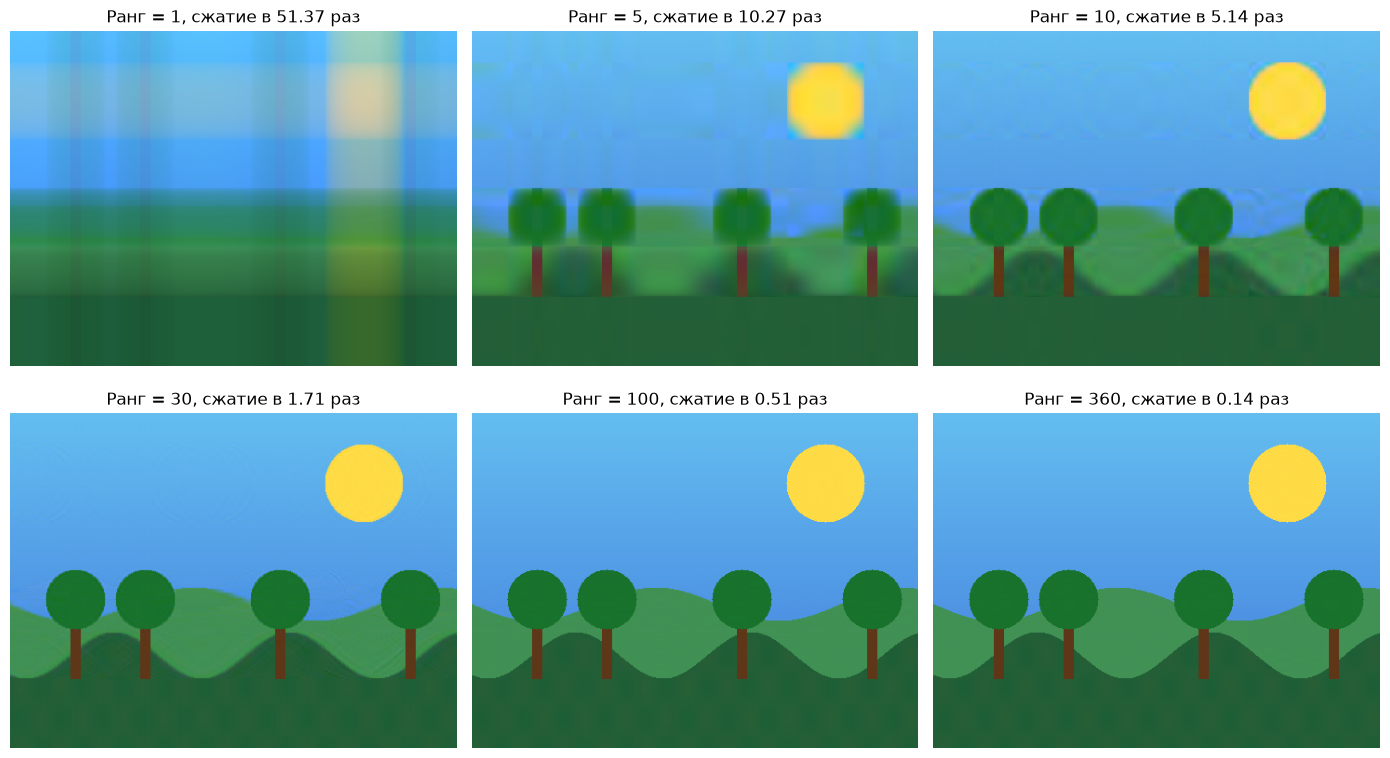

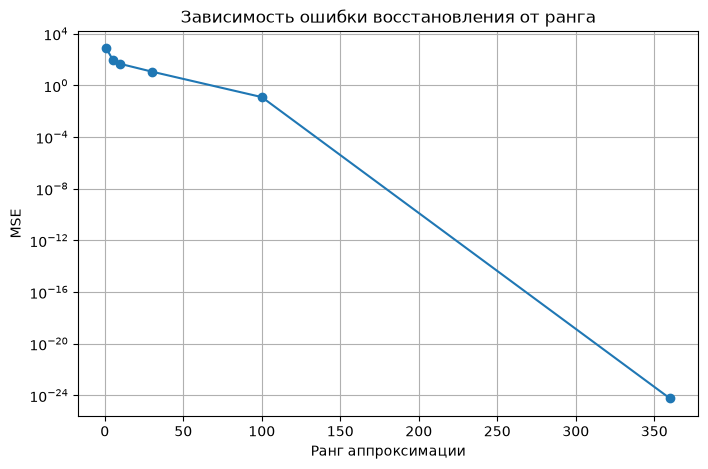

In [5]:
# Создаю список для восстановленных изображений.
approximations = []
# Создаю список среднеквадратичных ошибок.
mse_list = []
# Создаю список коэффициентов сжатия по формуле из задания.
compression_results = []
# Считаю исходный размер RGB-изображения в байтах при одном байте на канал.
original_size_bytes = height * width * 3
# Перебираю все требуемые ранги.
for rank in list_of_ranks:
    # Восстанавливаю изображение для текущего ранга.
    approximation = reconstruct_rgb(rank)
    # Сохраняю восстановленный массив без округления, чтобы считать ошибку точнее.
    approximations.append(approximation)
    # Считаю среднеквадратичную ошибку по всем пикселям и каналам.
    mse = float(np.mean((image_array - approximation) ** 2))
    # Сохраняю MSE.
    mse_list.append(mse)
    # Считаю количество чисел в трёх наборах факторов U, Sigma и V^T.
    compressed_numbers = 3 * rank * (height + 1 + width)
    # Считаю размер сжатого представления при использовании float32.
    compressed_size_bytes = compressed_numbers * 4
    # Считаю коэффициент сжатия.
    compression_ratio = original_size_bytes / compressed_size_bytes
    # Сохраняю характеристики текущего ранга.
    compression_results.append({
        "rank": rank,
        "mse": mse,
        "compressed_bytes": compressed_size_bytes,
        "compression_ratio": compression_ratio,
    })
# Печатаю таблицу с результатами.
print("Ранг | MSE | Размер сжатого представления, байт | Коэффициент сжатия")
# Печатаю одну строку для каждого ранга.
for result in compression_results:
    print(result["rank"], result["mse"], result["compressed_bytes"], result["compression_ratio"])
# Вывожу восстановленные изображения на одном графике 2 x 3.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
# Перебираю оси и результаты одновременно.
for axis, rank, approximation, result in zip(axes.flat, list_of_ranks, approximations, compression_results):
    # Ограничиваю значения пикселей диапазоном 0...255.
    display_image = np.clip(approximation, 0, 255).astype(np.uint8)
    # Показываю восстановленное изображение.
    axis.imshow(display_image)
    # Подписываю каждый подграфик рангом и реальным коэффициентом сжатия.
    axis.set_title(f"Ранг = {rank}, сжатие в {result['compression_ratio']:.2f} раз")
    # Убираю координатные оси.
    axis.axis("off")
# Делаю расстояния между подграфиками удобными.
plt.tight_layout()
# Показываю общий рисунок.
plt.show()
# Строю график MSE от ранга.
plt.figure(figsize=(8, 5))
# Использую логарифмический масштаб по вертикали, чтобы видеть малые ошибки.
plt.semilogy(list_of_ranks, mse_list, "o-")
# Подписываю ось ранга.
plt.xlabel("Ранг аппроксимации")
# Подписываю ось ошибки.
plt.ylabel("MSE")
# Добавляю заголовок.
plt.title("Зависимость ошибки восстановления от ранга")
# Добавляю сетку.
plt.grid(True, which="both")
# Показываю график.
plt.show()

## Часть В–Г. Визуальный анализ и размер хранения

В таблице выше коэффициент сжатия рассчитан не по размеру PNG-файла, а по формуле задания: исходное RGB-изображение хранится как `height × width × 3` байта, а SVD-представление — как три набора чисел `float32`. Это честное сравнение именно двух способов хранения данных.

In [6]:
# Создаю папку для сохранения результата.
output_dir = Path("attached_assets/svd_results")
# Создаю папку, если её ещё нет.
output_dir.mkdir(parents=True, exist_ok=True)
# Сохраняю исходное изображение в PNG.
Image.fromarray(original_uint8).save(output_dir / "original.png")
# Перебираю ранги и восстановленные изображения.
for rank, approximation in zip(list_of_ranks, approximations):
    # Ограничиваю значения и перевожу их в формат PNG.
    approximation_uint8 = np.clip(approximation, 0, 255).astype(np.uint8)
    # Сохраняю восстановленное изображение.
    Image.fromarray(approximation_uint8).save(output_dir / f"rank_{rank}.png")
# Получаю фактический размер исходного PNG-файла.
original_png_size = (output_dir / "original.png").stat().st_size
# Печатаю путь сохранения файлов.
print("Файлы сохранены в:", output_dir)
# Печатаю фактический размер исходного PNG как дополнительную информацию.
print("Размер исходного PNG, байт:", original_png_size)

Файлы сохранены в: attached_assets/svd_results
Размер исходного PNG, байт: 7138


In [7]:
# ---------- БЛОК АВТОПРОВЕРКИ ----------
# Проверяю, что каждое восстановленное изображение имеет исходную форму.
for i, rank in enumerate(list_of_ranks):
    # Сравниваю форму текущего результата с формой оригинала.
    assert approximations[i].shape == original_shape, f"Неверная форма для ранга {rank}"
# Проверяю диапазон значений всех восстановленных изображений.
for i, rank in enumerate(list_of_ranks):
    # Ограничиваю значения для проверки диапазона пикселей.
    checked_array = np.clip(approximations[i], 0, 255)
    # Проверяю верхнюю границу значений.
    assert checked_array.max() <= 255.1, f"Слишком большие значения для ранга {rank}"
    # Проверяю нижнюю границу значений.
    assert checked_array.min() >= -0.1, f"Слишком маленькие значения для ранга {rank}"
# Проверяю, что список ошибок имеет такую же длину, как список рангов.
assert len(mse_list) == len(list_of_ranks), "Количество MSE не совпадает с количеством рангов"
# Проверяю монотонное уменьшение MSE с ростом ранга.
for i in range(1, len(mse_list)):
    # Добавляю маленький допуск на погрешность вычислений с плавающей точкой.
    assert mse_list[i] <= mse_list[i - 1] + 1e-6, "MSE не уменьшается"
# Проверяю, что максимальный ранг даёт почти точное восстановление.
assert mse_list[-1] < 1e-6, "Полное восстановление оказалось неточным"
# Вывожу сообщение об успешном прохождении проверок.
print("Все автоматические проверки пройдены. Задание выполнено корректно!")

Все автоматические проверки пройдены. Задание выполнено корректно!


## Итоговый вывод

SVD позволяет представить каждый цветовой канал изображения в виде произведения трёх матриц. Если оставить только первые сингулярные числа, получается приближённое изображение меньшего ранга. При ранге 1 сохраняется только самая общая структура изображения, поэтому детали сильно теряются. При увеличении ранга качество постепенно улучшается, а MSE уменьшается.

Для созданного изображения коэффициент сжатия больше 10 раз достигается уже при небольших рангах, потому что объём SVD-представления растёт линейно по рангу. Максимальный ранг даёт практически полное восстановление исходного изображения, но коэффициент сжатия становится меньше. 

Ошибка восстановления неодинакова для разных участков: крупные плавные области описываются небольшим числом сингулярных компонент, а мелкие детали и резкие границы требуют большего ранга. Поэтому SVD особенно хорошо сжимает изображения с большими однотонными областями и повторяющимися структурами.


Я применяла SVD отдельно к красному, зелёному и синему каналам. Для каждого канала оставляла только первые `r` сингулярных чисел и восстанавливала матрицу формулой `(U[:, :r] * s[:r]) @ Vt[:r, :]`. Чем меньше ранг, тем меньше чисел нужно хранить, но тем сильнее потеря качества. MSE показывает среднюю квадратную ошибку восстановления, а коэффициент сжатия сравнивает размер исходного RGB-массива с размером трёх SVD-представлений в формате `float32`.